In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/clean_retail_data.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Lag_7,Rolling_Mean_7,Promo_Effect,Inventory_Stress,Sales_Velocity,Product_Power,Month,DayOfWeek,Is_Weekend,Target_Log
0,2022-01-09,S004,P0001,Clothing,West,391,253,163,250.85,80.62,...,100.0,116.571429,0.000000,3.325638,0.952612,133.389488,1,6,1,5.537334
1,2022-01-11,S003,P0001,Clothing,North,366,6,147,7.29,42.12,...,83.0,138.428571,0.000000,2.625000,1.814549,133.389488,1,1,0,1.945910
2,2022-01-11,S005,P0001,Clothing,East,208,204,88,202.45,31.82,...,195.0,127.428571,0.314268,1.619577,0.046719,133.389488,1,1,0,5.323010
3,2022-01-15,S002,P0001,Clothing,West,79,19,163,16.28,62.09,...,39.0,128.714286,0.000000,0.609031,1.572687,133.389488,1,5,1,2.995732
4,2022-01-15,S003,P0001,Clothing,West,349,212,89,229.00,51.29,...,264.0,125.857143,0.097485,2.751126,0.149775,133.389488,1,5,1,5.361292


In [3]:
product_stats = df.groupby("Identity").agg({
    "Units Sold": ["mean","std","max"]
}).reset_index()

product_stats.columns = [
    "Identity",
    "Avg_Sales",
    "Sales_Volatility",
    "Max_Sales"
]

product_stats = product_stats.fillna(0)

product_stats.head()

,Identity,Avg_Sales,Sales_Volatility,Max_Sales
0,Clothing-P0001,133.549660,109.822298,434
1,Clothing-P0002,135.164557,107.321301,434
2,Clothing-P0003,130.692525,103.655264,434
3,Clothing-P0004,135.677557,109.569803,434
4,Clothing-P0005,140.039130,108.815792,434


In [4]:
features = ["Avg_Sales","Sales_Volatility","Max_Sales"]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(product_stats[features])

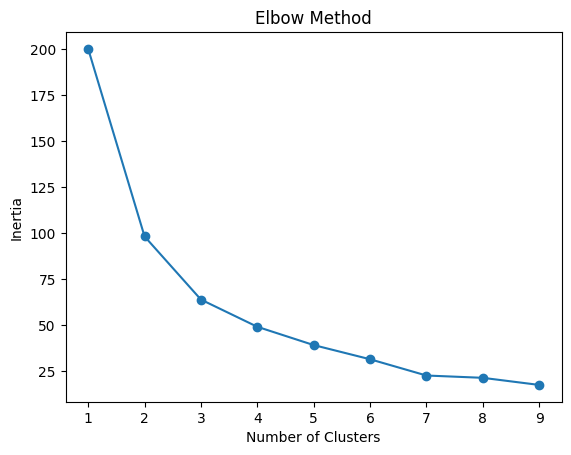

In [5]:
inertia = []

for k in range(1,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_stats["Cluster"] = kmeans.fit_predict(scaled_features)

product_stats.head()

,Identity,Avg_Sales,Sales_Volatility,Max_Sales,Cluster
0,Clothing-P0001,133.549660,109.822298,434,0
1,Clothing-P0002,135.164557,107.321301,434,0
2,Clothing-P0003,130.692525,103.655264,434,1
3,Clothing-P0004,135.677557,109.569803,434,0
4,Clothing-P0005,140.039130,108.815792,434,2


In [7]:
cluster_map = {
    0: "Slow Moving",
    1: "Medium",
    2: "Fast Moving"
}

product_stats["Segment"] = product_stats["Cluster"].map(cluster_map)

product_stats.head()

,Identity,Avg_Sales,Sales_Volatility,Max_Sales,Cluster,Segment
0,Clothing-P0001,133.549660,109.822298,434,0,Slow Moving
1,Clothing-P0002,135.164557,107.321301,434,0,Slow Moving
2,Clothing-P0003,130.692525,103.655264,434,1,Medium
3,Clothing-P0004,135.677557,109.569803,434,0,Slow Moving
4,Clothing-P0005,140.039130,108.815792,434,2,Fast Moving


In [8]:
fig = px.scatter(
    product_stats,
    x="Avg_Sales",
    y="Sales_Volatility",
    color="Segment",
    title="Product Clustering"
)

fig.show()

In [9]:
product_stats["Segment"].value_counts()

Segment
Slow Moving    48
Fast Moving    30
Medium         22
Name: count, dtype: int64